# Análisis de Errores: Falsos Negativos en Holdout
Este notebook carga el dataset de holdout (`test_real_traffic.feather`), evalúa el modelo Focal Loss (Exp2) con el umbral óptimo calibrado, e identifica qué clases de ataques específicos están siendo clasificados erróneamente como tráfico benigno.

In [1]:
import gc
gc.collect()

14

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import keras.backend as K

# Para Focal Loss
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        
        # Para la clase negativa
        cross_entropy_0 = -(1 - y_true) * K.log(1 - y_pred)
        weight_0 = (1 - alpha) * (1 - y_true) * K.pow(y_pred, gamma)
        loss_0 = weight_0 * cross_entropy_0
        
        return K.mean(loss + loss_0, axis=-1)
    return focal_loss_fixed

In [3]:
# Cargar umbrales
with open('thresholds_v2.json', 'r') as f:
    thresholds = json.load(f)
thr_exp2 = thresholds['exp2_r99']
print(f"Umbral óptimo a utilizar: {thr_exp2}")

# Cargar scaler para obtener las features seleccionadas
scaler = joblib.load('standard_scaler_binario_v2.pkl')
FEATURES_SELECCIONADAS = FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size',
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration',
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count'
]
print(f"Features seleccionadas ({len(FEATURES_SELECCIONADAS)}): {FEATURES_SELECCIONADAS}")

Umbral óptimo a utilizar: 0.45225340127944946
Features seleccionadas (18): ['iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size', 'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration', 'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count', 'rst_flag_number', 'ack_count']


In [4]:
# Cargar dataset de holdout
print("Cargando dataset de holdout...")
df_holdout = pd.read_feather('test_real_traffic.feather')

# Generar label_binario si no existe (asumiendo 'BenignTraffic' como benigno)
if 'label_binario' not in df_holdout.columns:
    df_holdout['label_binario'] = (df_holdout['label'] != 'BenignTraffic').astype(int)

# Preparar X e y
X_test = df_holdout[FEATURES_SELECCIONADAS]
y_test = df_holdout['label_binario']
labels_test = df_holdout['label']

# Escalar
X_test_scaled = scaler.transform(X_test)

Cargando dataset de holdout...


c:\Users\caos\.conda\envs\ids-iot-train\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
# Cargar modelo Exp2 (Focal Loss)
print("Cargando modelo...")
model = load_model('mlp_binario_v2_exp2_focalloss.h5',compile=False)

# Predecir probabilidades
print("Realizando predicciones...")
probs = model.predict(X_test_scaled, batch_size=1024).flatten()

# Aplicar umbral
preds = (probs > thr_exp2).astype(int)

Cargando modelo...
Realizando predicciones...
1140/1140 [==============================] - 3s 875us/step


In [7]:
# Identificar Falsos Negativos (Era malicioso = 1, pero se predijo como benigno = 0)
falsos_negativos_mask = (y_test == 1) & (preds == 0)
df_fn = df_holdout[falsos_negativos_mask].copy()

print(f"Total de Falsos Negativos: {len(df_fn)}")

Total de Falsos Negativos: 44779


In [8]:
# Análisis de Falsos Negativos por Clase de Ataque
fn_counts = df_fn['label'].value_counts()
total_ataques = df_holdout[df_holdout['label_binario'] == 1]['label'].value_counts()

# Calcular porcentaje de falla por clase
analisis_df = pd.DataFrame({
    'Falsos Negativos': fn_counts,
    'Total en Holdout': total_ataques
}).fillna(0)

analisis_df['% de Falla (FN / Total)'] = (analisis_df['Falsos Negativos'] / analisis_df['Total en Holdout']) * 100
analisis_df = analisis_df.sort_values(by='Falsos Negativos', ascending=False)

print("Distribución de Falsos Negativos por tipo de ataque:")
display(analisis_df[analisis_df['Falsos Negativos'] > 0])

Distribución de Falsos Negativos por tipo de ataque:


,Falsos Negativos,Total en Holdout,% de Falla (FN / Total)
label,,,
MITM-ArpSpoofing,12854.0,30759,41.789395
DNS_Spoofing,11425.0,17891,63.858923
Recon-OSScan,6900.0,9826,70.221860
Recon-HostDiscovery,5099.0,13438,37.944635
Recon-PortScan,4997.0,8228,60.731648
DictionaryBruteForce,1169.0,1306,89.509954
BrowserHijacking,498.0,586,84.982935
CommandInjection,397.0,541,73.382625
SqlInjection,387.0,524,73.854962


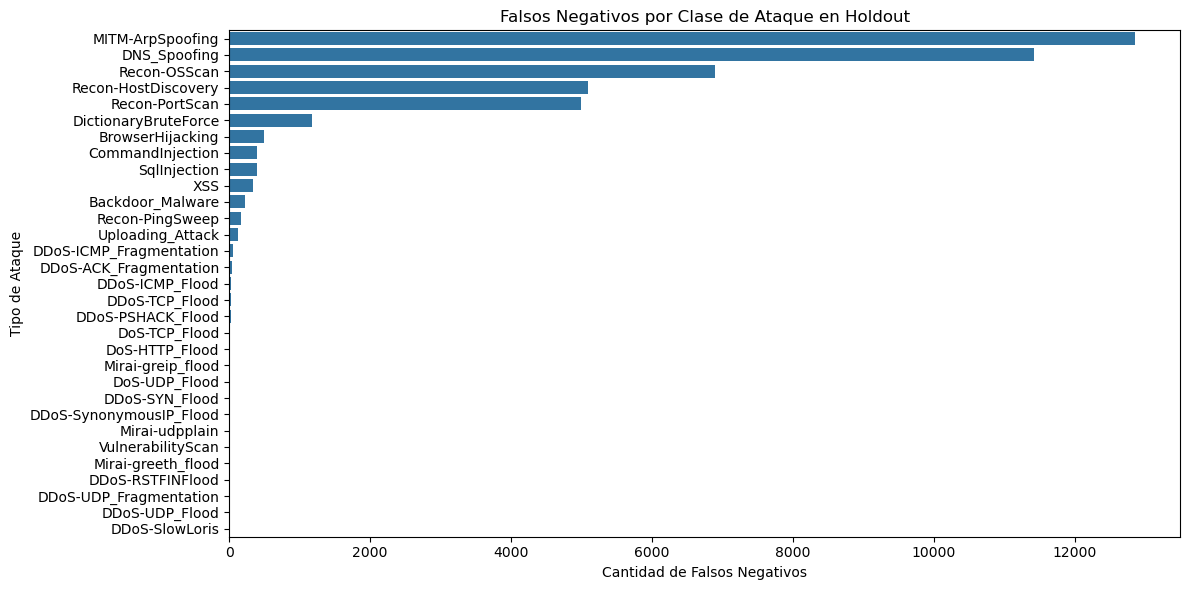

In [9]:
# Visualización
plt.figure(figsize=(12, 6))
sns.barplot(x=analisis_df[analisis_df['Falsos Negativos'] > 0]['Falsos Negativos'], 
            y=analisis_df[analisis_df['Falsos Negativos'] > 0].index)
plt.title('Falsos Negativos por Clase de Ataque en Holdout')
plt.xlabel('Cantidad de Falsos Negativos')
plt.ylabel('Tipo de Ataque')
plt.tight_layout()
plt.savefig('falsos_negativos_distribucion.png')
plt.show()